<a href="https://colab.research.google.com/github/sudhars97/Project-files/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies
!pip install kaggle imbalanced-learn xgboost shap

# Mount Google Drive (store your dataset here)
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
df = pd.read_csv('drive/MyDrive/creditcard.csv')
df.head()


Mounted at /content/drive


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


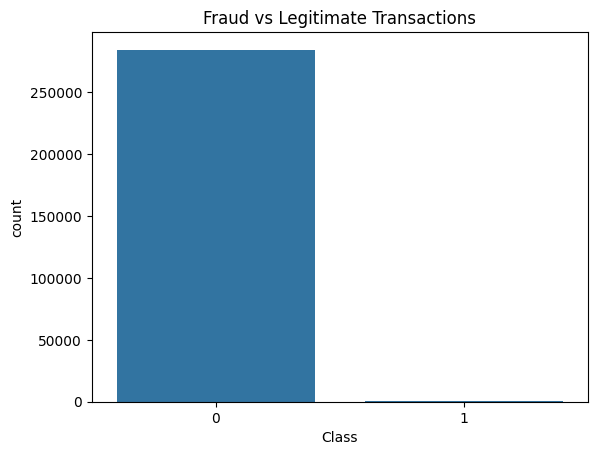

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class imbalance
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Legitimate Transactions')

# Amount distribution by class
df.groupby('Class')['Amount'].describe()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Scale Amount and Time (V1–V28 are already PCA-transformed)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE only on training data (NEVER on test — avoids data leakage)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=100, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    print(f"{name} trained ✓")


Logistic Regression trained ✓
Random Forest trained ✓
XGBoost trained ✓


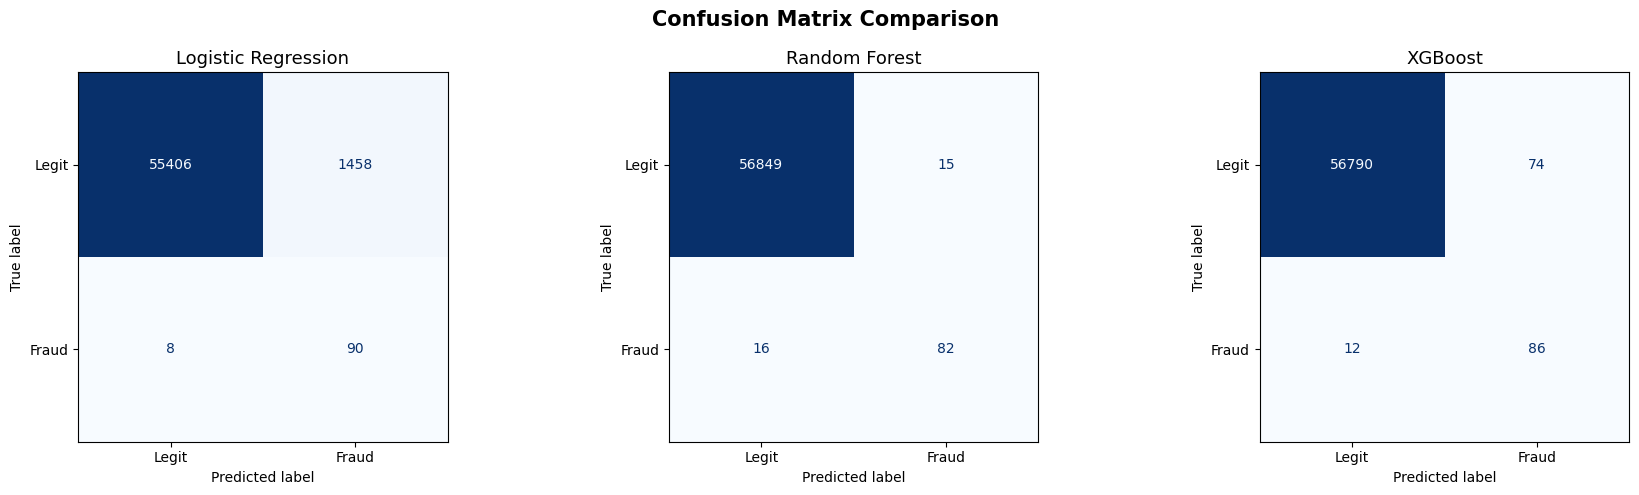

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}", fontsize=13)

plt.suptitle("Confusion Matrix Comparison", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_pred, y_test, target_names=["Legit", "Fraud"], output_dict=True)
    df_report = pd.DataFrame(report).transpose().round(3)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(df_report.to_string())



  Logistic Regression
              precision  recall  f1-score    support
Legit             0.974   1.000     0.987  55414.000
Fraud             0.918   0.058     0.109   1548.000
accuracy          0.974   0.974     0.974      0.974
macro avg         0.946   0.529     0.548  56962.000
weighted avg      0.973   0.974     0.963  56962.000

  Random Forest
              precision  recall  f1-score    support
Legit             1.000   1.000     1.000  56865.000
Fraud             0.837   0.845     0.841     97.000
accuracy          0.999   0.999     0.999      0.999
macro avg         0.918   0.923     0.920  56962.000
weighted avg      0.999   0.999     0.999  56962.000

  XGBoost
              precision  recall  f1-score    support
Legit             0.999   1.000     0.999  56802.000
Fraud             0.878   0.538     0.667    160.000
accuracy          0.998   0.998     0.998      0.998
macro avg         0.938   0.769     0.833  56962.000
weighted avg      0.998   0.998     0.998  56962

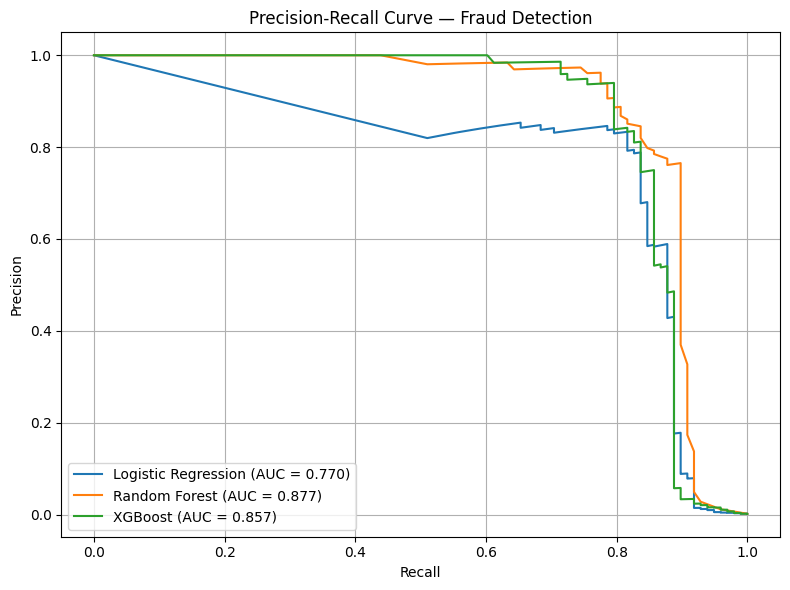

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Fraud Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()


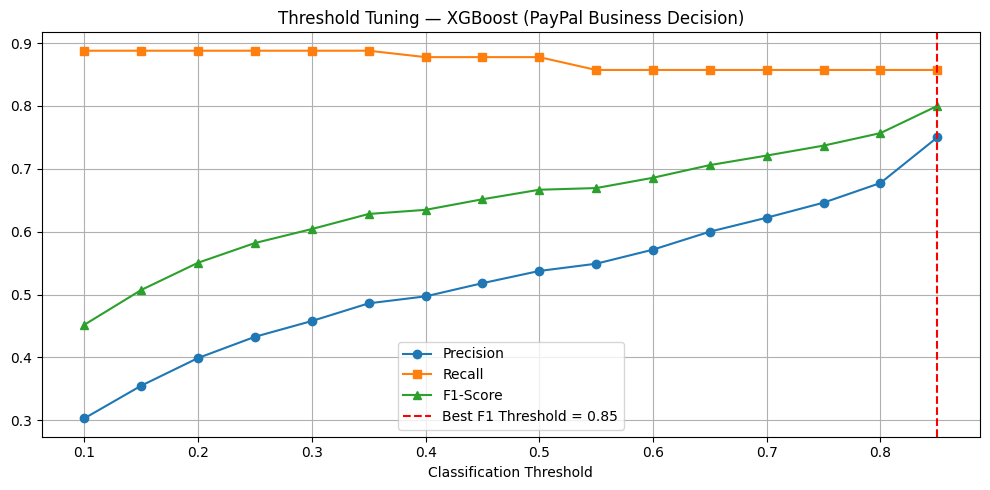

Best threshold: 0.85 | F1: 0.800


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

xgb_model = models["XGBoost"]
y_scores = xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='s')
plt.plot(thresholds, f1s, label='F1-Score', marker='^')
plt.axvline(x=thresholds[np.argmax(f1s)], color='red', linestyle='--', label=f'Best F1 Threshold = {thresholds[np.argmax(f1s)]:.2f}')
plt.xlabel("Classification Threshold")
plt.title("Threshold Tuning — XGBoost (PayPal Business Decision)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150)
plt.show()

print(f"Best threshold: {thresholds[np.argmax(f1s)]:.2f} | F1: {max(f1s):.3f}")


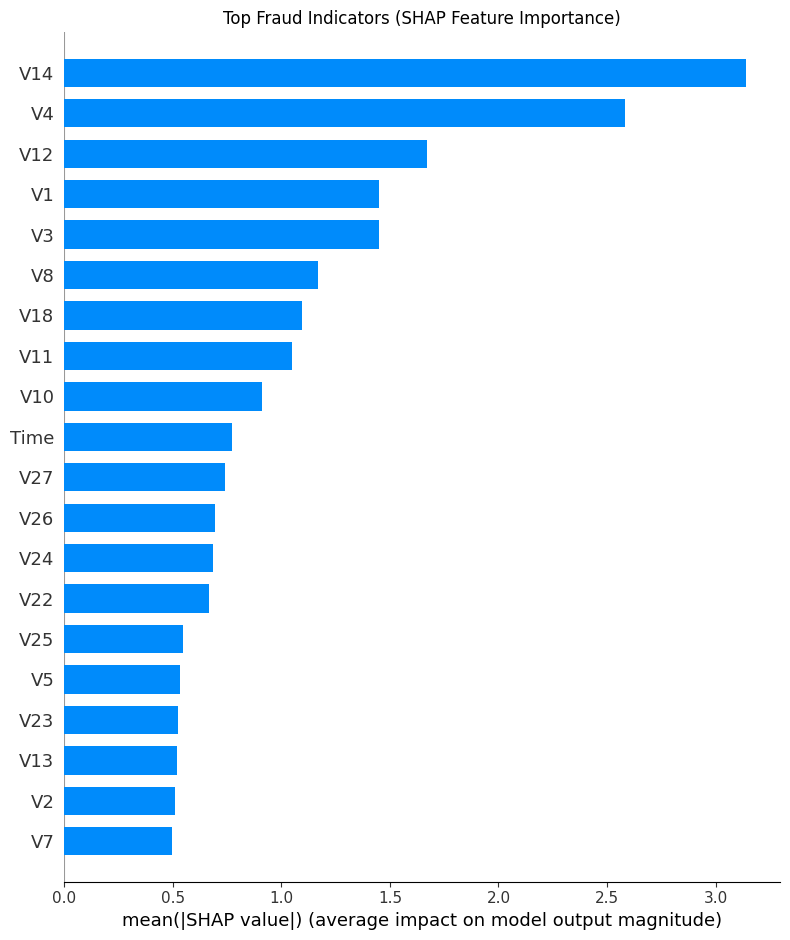

In [ ]:
import shap

explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test.iloc[:500])

# Summary plot — feature importance with directionality
plt.figure()
shap.summary_plot(shap_values, X_test.iloc[:500], plot_type="bar", show=False)
plt.title("Top Fraud Indicators (SHAP Feature Importance)")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()
